# Comparison with ATLAS ITk Events with collision essentially removed

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

from utils import load_config_data, get_hist_data

**Points of comparison**
For a specific configuration of the simulation (pt = 150MeV, eta = [-4, 4], with neutrals, with secondaries):
- For ITk, go back to the root file to get particle list (particularly, low pt and neutrals)
- How many target particles (be very explicit and apples to apples)
- How many target hits vs eta (theory that high eta in ITk is giving many target hits)
- How many background hits (low pt primary, or secondary) vs eta
- How many hits per target and background particle
- How many neutral hits per neutral particle in ODD?

## Load ODD Data

In [71]:
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison")
config_name = "config_pt100_postpt0.01_eta-4.0_4.0_neutralsFalse_secondariesTrue"
odd_hits, odd_particles, odd_pythia = load_config_data(base_dir, config_name)

100%|██████████| 32/32 [02:12<00:00,  4.15s/it]


In [72]:
# Create masks for each condition
target_mask = (
    (odd_particles.vertex_secondary == 0) &
    (odd_particles.q != 0) &
    (odd_particles.pt > 1) &
    (odd_particles.number_of_hits >= 1)
)

background_mask = (
    (odd_particles.q != 0) &
    (
        (odd_particles.pt < 1) |
        (odd_particles.vertex_secondary != 0)
    ) &
    (odd_particles.number_of_hits >= 1)
)

neutral_mask = (
    (odd_particles.q == 0) &
    (odd_particles.number_of_hits >= 1)
)

target_particles = odd_particles[target_mask]
background_particles = odd_particles[background_mask]
neutral_particles = odd_particles[neutral_mask]
noise_particles = odd_particles[~target_mask & ~background_mask & ~neutral_mask]

# Calculate statistics
n_events = len(odd_particles.event_id.unique())
print(f"Total particles per event: {len(odd_particles) / n_events:.2f}")
print(f"Target particles per event: {len(target_particles) / n_events:.2f}")
print(f"Background particles per event: {len(background_particles) / n_events:.2f}")
print(f"Neutral particles per event: {len(neutral_particles) / n_events:.2f}")
print(f"Noise particles per event: {len(noise_particles) / n_events:.2f}")

Total particles per event: 25243.11
Target particles per event: 1145.18
Background particles per event: 12976.46
Neutral particles per event: 11121.48
Noise particles per event: 0.00


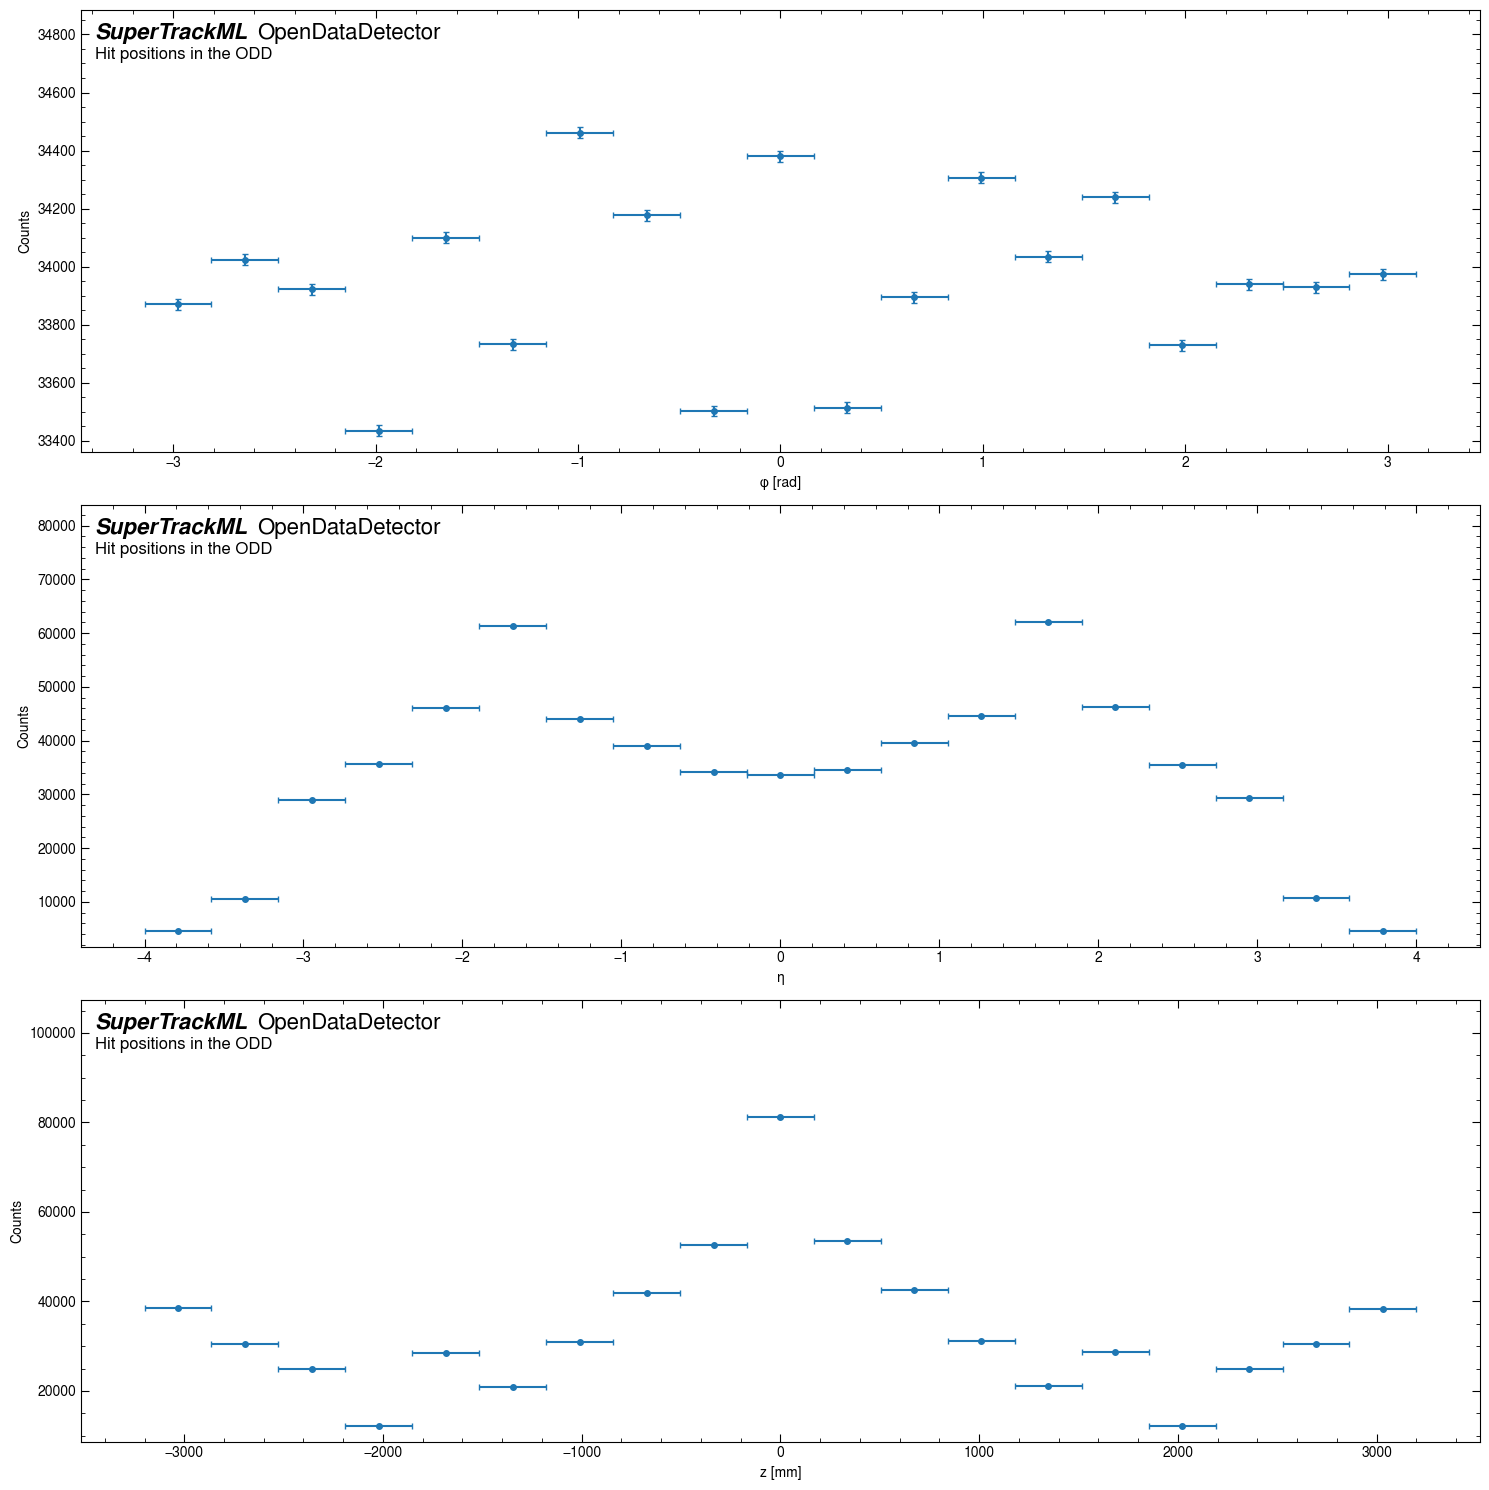

In [73]:
# First check the intermediate values
odd_hits["r"] = np.sqrt(odd_hits.tx**2 + odd_hits.ty**2)
odd_hits["phi"] = np.arctan2(odd_hits.ty, odd_hits.tx)

# Modified theta calculation to handle edge cases
odd_hits["theta"] = np.arctan2(np.sqrt(odd_hits.tx**2 + odd_hits.ty**2), odd_hits.tz)

# More robust eta calculation
odd_hits["eta"] = -np.log(np.tan(odd_hits.theta/2 + 1e-10))  # Add small epsilon to avoid exact 0/π

r_centers, r_counts, r_widths, r_errors = get_hist_data(odd_hits.r, np.linspace(0, 1200, 20), odd_hits.event_id)
phi_centers, phi_counts, phi_widths, phi_errors = get_hist_data(odd_hits.phi, np.linspace(-np.pi, np.pi, 20), odd_hits.event_id)
eta_centers, eta_counts, eta_widths, eta_errors = get_hist_data(odd_hits.eta, np.linspace(-4, 4, 20), odd_hits.event_id)
z_centers, z_counts, z_widths, z_errors = get_hist_data(odd_hits.tz, np.linspace(-3200, 3200, 20), odd_hits.event_id)

fig, axs = plt.subplots(3, 1, figsize=(15, 15))
axs[0].errorbar(phi_centers, phi_counts, yerr=phi_errors, xerr=phi_widths, 
            fmt='o', label='phi', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[0])
axs[0].set_xlabel("φ [rad]")
axs[0].set_ylabel("Counts")

axs[1].errorbar(eta_centers, eta_counts, yerr=eta_errors, xerr=eta_widths, 
            fmt='o', label='eta', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[1])
axs[1].set_xlabel("η")
axs[1].set_ylabel("Counts")

axs[2].errorbar(z_centers, z_counts, yerr=z_errors, xerr=z_widths, 
            fmt='o', label='z', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Hit positions in the ODD", axes=axs[2])
axs[2].set_xlabel("z [mm]")
axs[2].set_ylabel("Counts")

plt.tight_layout()
plt.show()

In [74]:
odd_hits = odd_hits.drop(columns=["index"])
odd_hits["hit_id"] = odd_hits.index

# Merge hits to target particles on both particle_id and event_id
target_hits = odd_hits.merge(target_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
background_hits = odd_hits.merge(background_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])
neutral_hits = odd_hits.merge(neutral_particles, on=["event_id", "particle_id"], how="inner", suffixes=["", "_particles"])

# Now we can safely use pandas index for the noise hits identification
noise_hits = odd_hits[~odd_hits.hit_id.isin(target_hits.hit_id) & 
                     ~odd_hits.hit_id.isin(background_hits.hit_id) & 
                     ~odd_hits.hit_id.isin(neutral_hits.hit_id)]

print(f"Total hits per event: {len(odd_hits) / n_events:.2f}")
print(f"Target hits per event: {len(target_hits) / n_events:.2f}")
print(f"Background hits per event: {len(background_hits) / n_events:.2f}")
print(f"Neutral hits per event: {len(neutral_hits) / n_events:.2f}")
print(f"Noise hits per event: {len(noise_hits) / n_events:.2f}")

Total hits per event: 645167.30
Target hits per event: 13901.56
Background hits per event: 131238.15
Neutral hits per event: 104706.53
Noise hits per event: 395321.06


In [75]:
# Find overlaps between categories
target_keys = set(target_hits.hit_id)
background_keys = set(background_hits.hit_id)
neutral_keys = set(neutral_hits.hit_id)
noise_keys = set(noise_hits.hit_id)
print(f"Overlap between categories:")
print(f"Target & Background: {len(target_keys & background_keys)}")
print(f"Target & Neutral: {len(target_keys & neutral_keys)}")
print(f"Target & Noise: {len(target_keys & noise_keys)}")
print(f"Background & Neutral: {len(background_keys & neutral_keys)}")
print(f"Background & Noise: {len(background_keys & noise_keys)}")
print(f"Neutral & Noise: {len(neutral_keys & noise_keys)}")


Overlap between categories:
Target & Background: 0
Target & Neutral: 0
Target & Noise: 0
Background & Neutral: 0
Background & Noise: 0
Neutral & Noise: 0


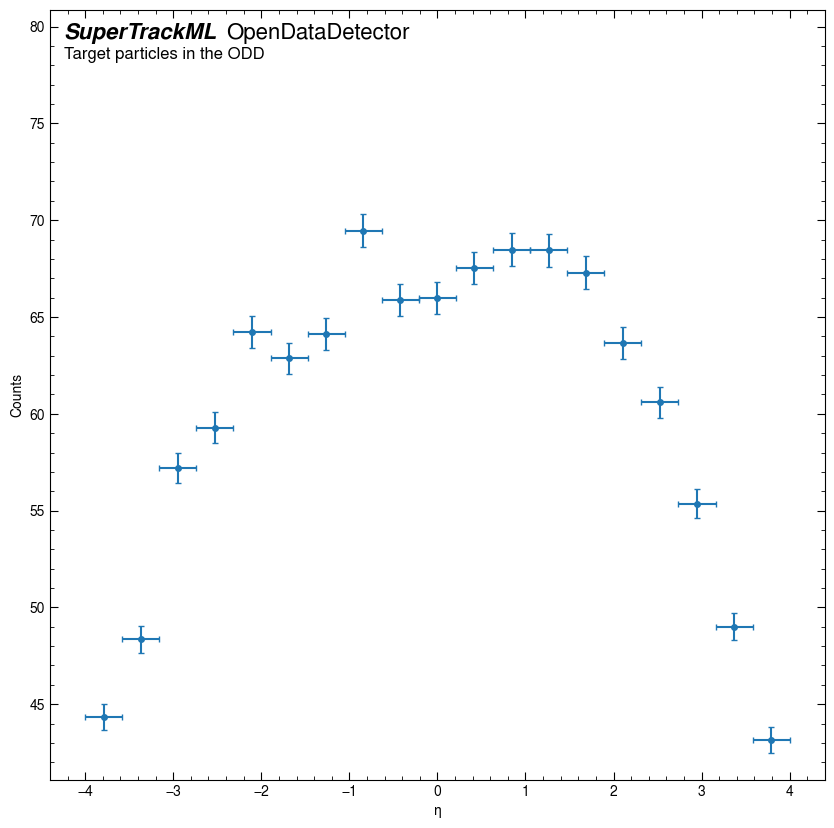

In [76]:
target_eta_centers, target_eta_counts, target_eta_widths, target_eta_errors = get_hist_data(target_particles.eta, np.linspace(-4, 4, 20), target_particles.event_id)
plt.figure(figsize=(10, 10))
plt.errorbar(target_eta_centers, target_eta_counts, yerr=target_eta_errors, xerr=target_eta_widths, 
            fmt='o', label='Target', markersize=4, capsize=2)
atl.atlasify("OpenDataDetector", "Target particles in the ODD", axes=plt.gca())
plt.xlabel("η")
plt.ylabel("Counts")
plt.show()


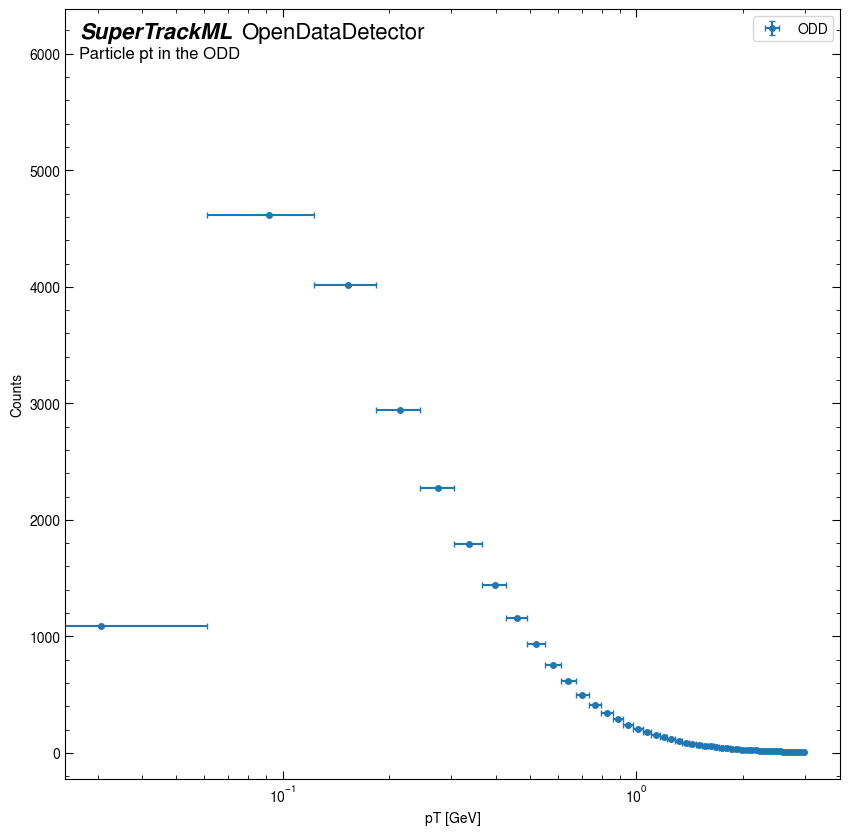

In [77]:
odd_pt_centers, odd_pt_counts, odd_pt_widths, odd_pt_errors = get_hist_data(odd_particles.pt, np.linspace(0, 3, 50), odd_particles.event_id)

plt.figure(figsize=(10, 10))
plt.errorbar(odd_pt_centers, odd_pt_counts, yerr=odd_pt_errors, xerr=odd_pt_widths, 
            fmt='o', label='ODD', markersize=4, capsize=2)
plt.xlabel("pT [GeV]")
plt.ylabel("Counts")
# x axis is log scale
plt.xscale("log")
atl.atlasify("OpenDataDetector", "Particle pt in the ODD", axes=plt.gca())
plt.legend()
plt.show()

## Load ITk Data

In [39]:
import athena_root_utils, athena_utils, athena_datatypes

In [40]:
itk_directory  = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/feature_store/valset"
itk_hit_files = sorted(glob.glob(itk_directory + "/*-truth.csv"))
itk_particle_files = sorted(glob.glob(itk_directory + "/*-particles.csv"))


In [41]:
itk_hit_files[0]

'/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/feature_store/valset/event000001150-truth.csv'

In [42]:
itk_hits_csv = pd.read_csv(itk_hit_files[0])
itk_hits_csv = itk_hits_csv.drop_duplicates(subset="hit_id")
itk_particles_csv = pd.read_csv(itk_particle_files[0])
itk_particles_csv.pt /= 1000 # Convert to GeV

In [43]:
itk_hit_csv

NameError: name 'itk_hit_csv' is not defined

In [94]:
itk_target_mask_csv = (
    (itk_particles_csv.charge != 0) &
    (itk_particles_csv.pt > 1) &
    (itk_particles_csv.barcode.astype(int) < 200000)
)
itk_background_mask_csv = ( 
    (itk_particles_csv.charge != 0) &
    (
        (itk_particles_csv.pt < 1) |
        (itk_particles_csv.barcode.astype(int) >= 200000)
    )
)

itk_target_particles = itk_particles_csv[itk_target_mask_csv]
itk_background_particles = itk_particles_csv[itk_background_mask_csv]
print(f"Number of target particles: {len(itk_target_particles)}")
print(f"Number of background particles: {len(itk_background_particles)}")

Number of target particles: 1263
Number of background particles: 16066


Root file:
242020 1150 4 root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/data/atlas/atlaslocalgroupdisk/rucio/user/avallier/a7/50/user.avallier.38040858.EXT0._000168.Dump_GNN4Itk.root RDO.37737772._000219.pool.root.1

In [5]:
root_dir = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/root_files/user.avallier.mc21_14TeV.601229.PhPy8EG_A14_ttbar_hdamp258p75_SingleLep.DumpGNN4ITk_v5.e8481_s4149_r15238_EXT0"
root_file = root_dir + "/user.avallier.38040858.EXT0._000168.Dump_GNN4Itk.root"

In [8]:
sample_list_file = root_dir + "/sample_lists/valid_set_ttbar_uncorr.txt"
# Read sample list text file to get mapping from event ID to root tree index
sample_list = pd.read_csv(sample_list_file, header=None, delimiter=" ")
sample_list.columns = ["run_id", "event_id", "root_index", "root_file", "rdo_file"]

In [10]:
sample_list.head()

,run_id,event_id,root_index,root_file,rdo_file
0,242020,6800,0,root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/d...,RDO.37737772._000213.pool.root.1
1,242020,6804,1,root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/d...,RDO.37737772._000213.pool.root.1
2,242020,6810,2,root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/d...,RDO.37737772._000213.pool.root.1
3,242020,6806,3,root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/d...,RDO.37737772._000213.pool.root.1
4,242020,6803,4,root://ccxrdatlastpc.in2p3.fr//pnfs/in2p3.fr/d...,RDO.37737772._000213.pool.root.1


In [ ]:
# 1. Get the list of csv files to read

In [45]:
# Read itk root file
itk_tree = uproot.open(root_file)['GNN4ITk;1']
itk_tree.keys()

['run_number',
 'event_number',
 'nSE',
 'SEID',
 'nCL',
 'CLindex',
 'CLhardware',
 'CLx',
 'CLy',
 'CLz',
 'CLbarrel_endcap',
 'CLlayer_disk',
 'CLeta_module',
 'CLphi_module',
 'CLside',
 'CLmoduleID',
 'CLparticleLink_eventIndex',
 'CLparticleLink_barcode',
 'CLbarcodesLinked',
 'CLparticle_charge',
 'CLphis',
 'CLetas',
 'CLtots',
 'CLloc_direction1',
 'CLloc_direction2',
 'CLloc_direction3',
 'CLJan_loc_direction1',
 'CLJan_loc_direction2',
 'CLJan_loc_direction3',
 'CLpixel_count',
 'CLcharge_count',
 'CLloc_eta',
 'CLloc_phi',
 'CLglob_eta',
 'CLglob_phi',
 'CLeta_angle',
 'CLphi_angle',
 'CLnorm_x',
 'CLnorm_y',
 'CLnorm_z',
 'CLlocal_cov',
 'nPartEVT',
 'Part_event_number',
 'Part_barcode',
 'Part_px',
 'Part_py',
 'Part_pz',
 'Part_pt',
 'Part_eta',
 'Part_vx',
 'Part_vy',
 'Part_vz',
 'Part_radius',
 'Part_status',
 'Part_charge',
 'Part_pdg_id',
 'Part_passed',
 'Part_vProdNin',
 'Part_vProdNout',
 'Part_vProdStatus',
 'Part_vProdBarcode',
 'Part_vParentID',
 'Part_vParent

In [46]:
part_branches = itk_tree.arrays(
                athena_root_utils.particle_branch_names,
                entry_start=4,
                entry_stop=5,
                library="np",
            )
part_branches.keys()

particles = athena_root_utils.read_particles(part_branches)
particles = athena_utils.convert_barcodes(particles)
particles.pt /= 1000 # Convert to GeV
particles.particle_id = particles.particle_id.astype(str)

In [49]:
sp_branches = itk_tree.arrays(
                athena_root_utils.spacepoint_branch_names,
                entry_start=4,
                entry_stop=5,
                library="np",
            )

spacepoints = athena_root_utils.read_spacepoints(
                sp_branches, 999
            )
print(len(spacepoints))


330398


In [50]:
cl_branches = itk_tree.arrays(
                athena_root_utils.cluster_branch_names,
                entry_start=4,
                entry_stop=5,
                library="np",
            )


In [51]:
clusters = athena_root_utils.read_clusters(
                cl_branches, particles, False
            )

In [52]:
clusters

,cluster_id,hardware,cluster_x,cluster_y,cluster_z,barrel_endcap,layer_disk,eta_module,phi_module,side,...,lengthDir1,lengthDir2,glob_eta,glob_phi,eta_angle,phi_angle,norm_x,norm_y,norm_z,particle_id
0,0,PIXEL,11.340760,32.499437,-265.000,-2,0,0,0,0,...,0.000000,0.0,1.496611,2.181662,1.249046,1.249046,0.0,0.0,-1.0,0
1,1,PIXEL,0.583162,34.548606,-265.000,-2,0,0,0,0,...,0.000000,0.0,1.496611,2.181662,1.249046,1.249046,0.0,0.0,-1.0,4270010105
2,2,PIXEL,2.333990,34.976072,-265.000,-2,0,0,0,0,...,0.000000,0.0,1.103587,2.503412,1.249046,0.982794,0.0,0.0,-1.0,6100010199
3,3,PIXEL,12.474595,33.314938,-265.000,-2,0,0,0,0,...,0.000000,0.0,1.103587,1.859911,0.982794,1.249046,0.0,0.0,-1.0,4680010164
4,4,PIXEL,-1.324370,36.255781,-265.000,-2,0,0,0,0,...,0.000000,0.0,1.103587,1.859911,0.982794,1.249046,0.0,0.0,-1.0,4330010123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471568,469632,STRIP,924.360203,-157.628077,2860.715,2,5,17,63,1,...,-8.951639,0.0,0.005319,1.419991,1.324637,0.005319,0.0,0.0,-1.0,0
471569,469633,STRIP,925.856750,-148.586247,2860.715,2,5,17,63,1,...,-8.369587,0.0,0.005319,1.419991,1.324637,0.005319,0.0,0.0,-1.0,0
471570,469634,STRIP,926.398344,-145.171548,2860.715,2,5,17,63,1,...,-8.149831,0.0,0.005319,1.419991,1.324637,0.005319,0.0,0.0,-1.0,0
471571,469635,STRIP,929.816570,-121.368603,2860.715,2,5,17,63,1,...,-6.618856,0.0,0.005319,1.419991,1.324637,0.005319,0.0,0.0,-1.0,0


In [53]:
truth = athena_utils.get_truth_spacepoints(
                spacepoints, clusters, athena_datatypes.SPACEPOINTS_DATATYPES
            )
truth.drop_duplicates(subset="hit_id", inplace=True)
truth.particle_id = truth.particle_id.astype(str)

In [54]:
truth

,hit_id,x,y,z,cluster_index_1,cluster_index_2,SPisOverlap,hardware,cluster_x_1,cluster_y_1,...,lengthDir2_2,glob_eta_2,glob_phi_2,eta_angle_2,phi_angle_2,norm_x_2,norm_y_2,norm_z_2,particle_id_2,particle_id
0,0,11.340760,32.499437,-265.000,0,0,-1,PIXEL,11.340759,32.499435,...,0.0,1.496611,2.181662,1.249046,1.249046,0.0,0.0,-1.0,0,0
1,1,0.583162,34.548606,-265.000,1,1,-1,PIXEL,0.583162,34.548607,...,0.0,1.496611,2.181662,1.249046,1.249046,0.0,0.0,-1.0,4270010105,4270010105
2,2,2.333990,34.976072,-265.000,2,2,-1,PIXEL,2.333990,34.976070,...,0.0,1.103587,2.503412,1.249046,0.982794,0.0,0.0,-1.0,6100010199,6100010199
3,3,12.474595,33.314938,-265.000,3,3,-1,PIXEL,12.474595,33.314938,...,0.0,1.103587,1.859911,0.982794,1.249046,0.0,0.0,-1.0,4680010164,4680010164
4,4,-1.324370,36.255781,-265.000,4,4,-1,PIXEL,-1.324370,36.255783,...,0.0,1.103587,1.859911,0.982794,1.249046,0.0,0.0,-1.0,4330010123,4330010123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330713,330393,723.031411,-223.885468,2839.285,469457,469533,2,STRIP,748.930115,-232.509109,...,0.0,0.005863,1.319188,1.339333,0.005863,0.0,0.0,-1.0,0,0
330714,330394,770.921351,-232.102078,2839.285,469458,469533,2,STRIP,751.021912,-225.661301,...,0.0,0.005863,1.319188,1.339333,0.005863,0.0,0.0,-1.0,0,0
330715,330395,725.045420,-217.274626,2839.285,469458,469534,2,STRIP,751.021912,-225.661301,...,0.0,0.005862,1.316428,0.955698,0.005862,0.0,0.0,-1.0,0,0
330716,330396,654.855147,-61.661885,2854.285,469556,457421,2,STRIP,651.840820,-61.342583,...,0.0,0.009931,1.514674,1.350388,0.009930,0.0,0.0,-1.0,0,0


In [55]:
itk_target_mask = (
    (particles.charge != 0) &
    (particles.pt > 1) &
    (particles.barcode.astype(int) < 200000) &
    (particles.particle_id.astype(str).isin(truth.particle_id.astype(str)))
)

itk_background_mask = (
    (particles.charge != 0) &
    (
        (particles.pt < 1) |
        (particles.barcode.astype(int) >= 200000)
    ) &
    (particles.particle_id.astype(str).isin(truth.particle_id.astype(str)))
)
itk_neutral_mask = (
    (particles.charge == 0) &
    (particles.particle_id.astype(str).isin(truth.particle_id.astype(str)))
)

itk_nohit_mask = ~particles.particle_id.astype(str).isin(truth.particle_id.astype(str))

itk_target_particles = particles[itk_target_mask]
itk_background_particles = particles[itk_background_mask]
itk_neutral_particles = particles[itk_neutral_mask]
itk_nohit_particles = particles[itk_nohit_mask]
itk_noise_particles = particles[~itk_target_mask & ~itk_background_mask & ~itk_neutral_mask]

print(f"Number of target particles: {len(itk_target_particles)}")
print(f"Number of background particles: {len(itk_background_particles)}")
print(f"Number of neutral particles: {len(itk_neutral_particles)}")
print(f"Number of no hit particles: {len(itk_nohit_particles)}")
print(f"Number of noise particles: {len(itk_noise_particles)}")

Number of target particles: 1261
Number of background particles: 15174
Number of neutral particles: 6
Number of no hit particles: 90628
Number of noise particles: 90628


In [56]:
itk_target_hits = truth.merge(itk_target_particles, on="particle_id", how="inner")
itk_background_hits = truth.merge(itk_background_particles, on="particle_id", how="inner")
itk_neutral_hits = truth.merge(itk_neutral_particles, on="particle_id", how="inner")
itk_nohit_hits = truth.merge(itk_nohit_particles, on="particle_id", how="inner")
itk_noise_hits = truth[~truth.hit_id.isin(itk_target_hits.hit_id) & ~truth.hit_id.isin(itk_background_hits.hit_id) & ~truth.hit_id.isin(itk_neutral_hits.hit_id)]

print(f"Total hits: {len(truth)}")
print(f"Number of target hits: {len(itk_target_hits)}")
print(f"Number of background hits: {len(itk_background_hits)}")
print(f"Number of neutral hits: {len(itk_neutral_hits)}")
print(f"Number of no hit hits: {len(itk_nohit_hits)}")
print(f"Number of noise hits: {len(itk_noise_hits)}")

Total hits: 330398
Number of target hits: 14531
Number of background hits: 129625
Number of neutral hits: 7
Number of no hit hits: 0
Number of noise hits: 186235


In [57]:
itk_target_mask.sum()

1261

In [58]:
(particles["pass"] == 1).sum()

1270

In [59]:
itk_hits_csv.particle_id

0                  0
1         4270010105
2         6100010199
3         4680010164
4         4330010123
             ...    
330713             0
330714             0
330715             0
330716             0
330717             0
Name: particle_id, Length: 330398, dtype: int64

In [60]:
itk_target_particles.particle_id.astype(str).isin(itk_hits_csv.particle_id.astype(str)).sum()

1261

In [61]:
itk_background_particles.particle_id.astype(str).isin(itk_hits_csv.particle_id.astype(str)).sum()

15174

In [62]:
itk_target_particles.particle_id.astype(str).isin(truth.particle_id.astype(str)).sum()

1261

In [63]:
# Number of hits per particle
hits_per_particle = truth.groupby("particle_id").size()
hits_per_particle.value_counts()

1         1365
2         1121
9         1055
10         989
3          976
6          971
7          965
5          961
8          952
13         894
14         883
4          864
12         854
11         821
15         794
16         695
17         478
18         363
19         207
20         105
21          68
22          32
23          15
24           7
25           3
26           2
186235       1
27           1
dtype: int64

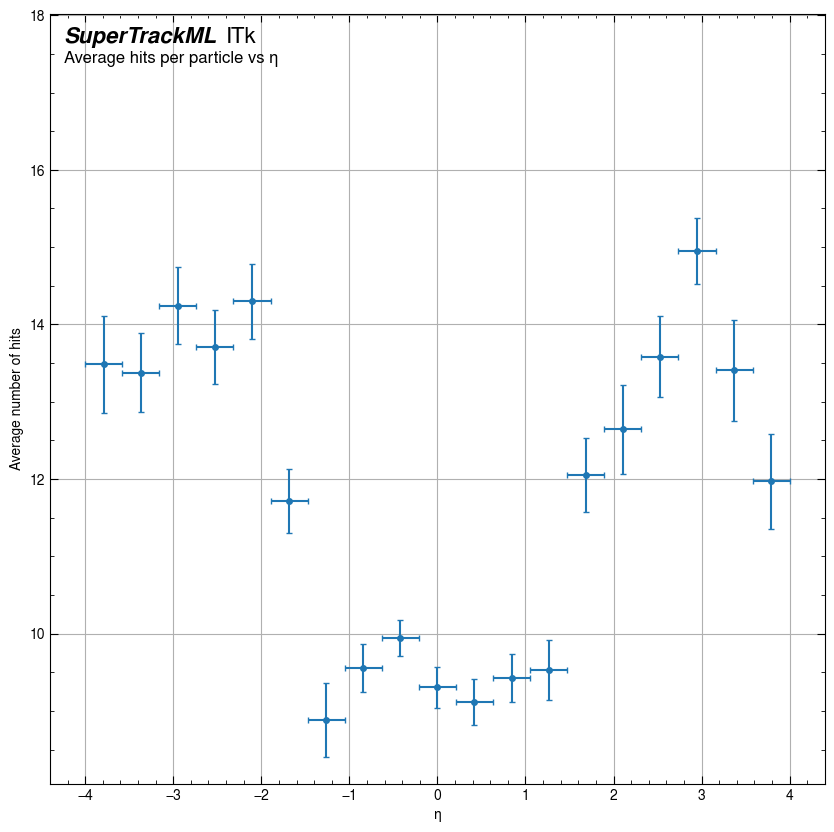

In [70]:
# Calculate hits per target particle and merge with particle information
hits_per_particle = itk_target_hits.groupby("particle_id").size().reset_index(name="n_hits")
particle_stats = itk_target_particles.merge(hits_per_particle, left_on="particle_id", right_on="particle_id", how="inner")

# Create eta bins and calculate mean hits per bin
eta_bins = np.linspace(-4, 4, 20)
eta_centers = (eta_bins[:-1] + eta_bins[1:]) / 2
mean_hits = []
std_hits = []

for i in range(len(eta_bins)-1):
    mask = (particle_stats.eta >= eta_bins[i]) & (particle_stats.eta < eta_bins[i+1])
    mean_hits.append(particle_stats[mask].n_hits.mean())
    std_hits.append(particle_stats[mask].n_hits.std() / np.sqrt(len(particle_stats[mask])))  # Standard error

# Calculate asymmetric error bars for log-spaced bins
xerr_left = eta_centers - eta_bins[:-1]
xerr_right = eta_bins[1:] - eta_centers
xerr = np.array([xerr_left, xerr_right])

# Plot with asymmetric error bars
plt.figure(figsize=(10, 10))
plt.errorbar(eta_centers, mean_hits, xerr=xerr, yerr=std_hits, fmt='o', markersize=4, capsize=2)
plt.xlabel("η")
plt.ylabel("Average number of hits")
atl.atlasify("ITk", "Average hits per particle vs η", axes=plt.gca())
plt.grid(True)
plt.show()

## Direct Comparisons

**Plan**

Directly compare between ITk and ODD:
- Total target particle hits across eta
- Total background particle hits across eta
- Total noise hits acorss eta
- Hits per target particle across eta
- Hits per background particle across eta

In [2]:
import athena_root_utils
import athena_utils
import athena_datatypes

def process_odd_data(hits_df, particles_df):
    """Process ODD data and return categorized hits and particles
    
    Returns:
        dict: Contains processed DataFrames for hits and particles by category
    """
    n_events = len(particles_df.event_id.unique())

    # Create particle masks
    target_mask = (
        (particles_df.vertex_secondary == 0) &
        (particles_df.q != 0) &
        (particles_df.pt > 1) &
        (particles_df.number_of_hits >= 1)
    )
    
    background_mask = (
        (particles_df.q != 0) &
        (
            (particles_df.pt < 1) |
            (particles_df.vertex_secondary != 0)
        ) &
        (particles_df.number_of_hits >= 1)
    )
    
    neutral_mask = (
        (particles_df.q == 0) &
        (particles_df.number_of_hits >= 1)
    )

    reconstructable_target_mask = (
        (particles_df.vertex_secondary == 0) &
        (particles_df.q != 0) &
        (particles_df.pt > 1) &
        (particles_df.number_of_hits >= 7)
    )

    reconstructable_background_mask = (
        (particles_df.q != 0) &
        (
            (particles_df.pt < 1) |
            (particles_df.vertex_secondary != 0)
        ) &
        (particles_df.number_of_hits >= 7)
    )
    
    # Categorize particles
    particles = {
        'target': particles_df[target_mask],
        'background': particles_df[background_mask],
        'reconstructable_target': particles_df[reconstructable_target_mask],
        'reconstructable_background': particles_df[reconstructable_background_mask],
        'neutral': particles_df[neutral_mask],
        'noise': particles_df[~target_mask & ~background_mask & ~neutral_mask]
    }
    
    # Process hits
    hits_df = hits_df.copy()
    hits_df = hits_df.drop(columns=["index"])
    hits_df["hit_id"] = hits_df.index
    
    # Calculate hit properties
    hits_df["r"] = np.sqrt(hits_df.tx**2 + hits_df.ty**2)
    hits_df["phi"] = np.arctan2(hits_df.ty, hits_df.tx)
    hits_df["theta"] = np.arctan2(np.sqrt(hits_df.tx**2 + hits_df.ty**2), hits_df.tz)
    hits_df["eta"] = -np.log(np.tan(hits_df.theta/2 + 1e-10))
    
    # Categorize hits
    hits = {}
    for category, particle_df in particles.items():
        if category != 'noise':
            hits[category] = hits_df.merge(
                particle_df, 
                on=["event_id", "particle_id"], 
                how="inner", 
                suffixes=["", "_particles"]
            )
    
    # Get noise hits (those not in any other category)
    categorized_hit_ids = set()
    for category in ['target', 'background', 'neutral']:
        if category in hits:
            categorized_hit_ids.update(hits[category].hit_id)
    hits['noise'] = hits_df[~hits_df.hit_id.isin(categorized_hit_ids)]

    # Printout the number of particles and hits per category PER EVENT
    print(f"=== ODD Statistics (per event) ===")
    print(f"Total hits: {len(hits_df) / n_events:.2f}")
    for category, hit_df in hits.items():
        print(f"Number of {category} hits: {len(hit_df) / n_events:.2f}")
    print(f"Total particles: {len(particles_df) / n_events:.2f}")
    for category, particle_df in particles.items():
        print(f"Number of {category} particles: {len(particle_df) / n_events:.2f}")
    
    return {'hits': hits, 'particles': particles, 'n_events': n_events}

def process_itk_data(root_file, start_event=0, n_events=1):
    """Process ITk data from root file for multiple events
    
    Args:
        root_file: Path to ITk root file
        start_event: First event to process
        n_events: Number of events to process
    
    Returns:
        dict: Contains processed DataFrames for hits and particles by category
    """
    # Read ITk root file
    itk_tree = uproot.open(root_file)['GNN4ITk;1']
    
    all_particles = []
    all_truth = []
    
    # Process each event
    for event_num in tqdm(range(start_event, start_event + n_events)):
        # Load particles
        part_branches = itk_tree.arrays(
            athena_root_utils.particle_branch_names,
            entry_start=event_num,
            entry_stop=event_num + 1,
            library="np"
        )
        particles_df = athena_root_utils.read_particles(part_branches)
        particles_df = athena_utils.convert_barcodes(particles_df)
        particles_df.pt /= 1000  # Convert to GeV
        particles_df.particle_id = particles_df.particle_id.astype(str)
        particles_df['event_id'] = event_num  # Add event ID
        
        # Load spacepoints and clusters
        sp_branches = itk_tree.arrays(
            athena_root_utils.spacepoint_branch_names,
            entry_start=event_num,
            entry_stop=event_num + 1,
            library="np"
        )
        cl_branches = itk_tree.arrays(
            athena_root_utils.cluster_branch_names,
            entry_start=event_num,
            entry_stop=event_num + 1,
            library="np"
        )
        
        spacepoints = athena_root_utils.read_spacepoints(sp_branches, 999)
        clusters = athena_root_utils.read_clusters(cl_branches, particles_df, False)
        truth = athena_utils.get_truth_spacepoints(
            spacepoints, clusters, athena_datatypes.SPACEPOINTS_DATATYPES
        )
        truth.drop_duplicates(subset="hit_id", inplace=True)
        truth.particle_id = truth.particle_id.astype(str)
        truth['event_id'] = event_num  # Add event ID

        # Calculate number of hits per particle for this event
        hits_per_particle = truth.groupby('particle_id').size().reset_index(name='number_of_hits')
        particles_df = particles_df.merge(
            hits_per_particle, 
            on='particle_id', 
            how='left'
        )
        particles_df['number_of_hits'] = particles_df['number_of_hits'].fillna(0)
                
        all_particles.append(particles_df)
        all_truth.append(truth)
    
    # Combine all events
    particles_df = pd.concat(all_particles, ignore_index=True)
    truth = pd.concat(all_truth, ignore_index=True)
    truth.drop(columns=["hit_id"], inplace=True)
    truth["hit_id"] = truth.index

    # Calculate hit properties
    truth["r"] = np.sqrt(truth.x**2 + truth.y**2)
    truth["phi"] = np.arctan2(truth.y, truth.x)
    truth["theta"] = np.arctan2(np.sqrt(truth.x**2 + truth.y**2), truth.z)
    truth["eta"] = -np.log(np.tan(truth.theta/2 + 1e-10))
    
    # Create particle masks
    target_mask = (
        (particles_df.charge != 0) &
        (particles_df.pt > 1) &
        (particles_df.barcode.astype(int) < 200000) &
        (particles_df.number_of_hits >= 1)
    )
    
    background_mask = (
        (particles_df.charge != 0) &
        (
            (particles_df.pt < 1) |
            (particles_df.barcode.astype(int) >= 200000)
        ) &
        (particles_df.number_of_hits >= 1)
    )
    
    neutral_mask = (
        (particles_df.charge == 0) &
        (particles_df.number_of_hits >= 1)
    )

    reconstructable_target_mask = (
        (particles_df.charge != 0) &
        (particles_df.pt > 1) &
        (particles_df.barcode.astype(int) < 200000) &
        (particles_df.number_of_hits >= 7)
    )

    reconstructable_background_mask = (
        (particles_df.charge != 0) &
        (
            (particles_df.pt < 1) |
            (particles_df.barcode.astype(int) >= 200000)
        ) &
        (particles_df.number_of_hits >= 7)
    )
    
    # Categorize particles and hits
    particles = {
        'target': particles_df[target_mask],
        'background': particles_df[background_mask],
        'reconstructable_target': particles_df[reconstructable_target_mask],
        'reconstructable_background': particles_df[reconstructable_background_mask],
        'neutral': particles_df[neutral_mask],
        'noise': particles_df[~target_mask & ~background_mask & ~neutral_mask]
    }
    
    hits = {}
    for category, particle_df in particles.items():
        if category != 'noise':
            hits[category] = truth.merge(
                particle_df, 
                on=["particle_id", "event_id"],  # Include event_id in merge
                how="inner",
                suffixes=["", "_particles"]
            )
    
    # Get noise hits
    categorized_hit_ids = set()
    for category in ['target', 'background', 'neutral']:
        if category in hits:
            categorized_hit_ids.update(hits[category].hit_id)
    hits['noise'] = truth[~truth.hit_id.isin(categorized_hit_ids)]

    # Printout the number of particles and hits per category PER EVENT
    print(f"=== ITk Statistics (per event) ===")
    print(f"Total hits: {len(truth) / n_events:.2f}")
    for category, hit_df in hits.items():
        print(f"Number of {category} hits: {len(hit_df) / n_events:.2f}")
    print(f"Total particles: {len(particles_df) / n_events:.2f}")
    for category, particle_df in particles.items():
        print(f"Number of {category} particles: {len(particle_df) / n_events:.2f}")
    
    return {'hits': hits, 'particles': particles, 'n_events': n_events}

def make_comparison_plot(odd_data, itk_data, categories, x_var='eta', 
                        bins=np.linspace(-4, 4, 20), plot_type='hits', title=None, subtext=None, save_dir="plots"):
    """Create comparison plot between ODD and ITk data with ratio panel and statistics box
    
    Args:
        odd_data: Processed ODD data dictionary
        itk_data: Processed ITk data dictionary
        categories: String or list of strings specifying categories to include
        x_var: Variable to plot on x-axis ('eta', 'pt', 'phi', etc.)
        bins: Bin edges for histogram
        plot_type: 'hits' or 'particles'
        title: Plot title (optional)
    """
    # Handle single category as string
    if isinstance(categories, str):
        categories = [categories]
        category_label = categories[0].capitalize()
    else:
        category_label = '+'.join(cat.capitalize() for cat in categories)
    
    fig = plt.figure(figsize=(10, 12))
    gs = plt.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    # Combine data from multiple categories
    odd_df = pd.concat([odd_data[plot_type][cat] for cat in categories])
    itk_df = pd.concat([itk_data[plot_type][cat] for cat in categories])
    
    # Calculate distributions
    odd_centers, odd_counts, odd_widths, odd_errors = get_hist_data(
        odd_df[x_var], bins, odd_df.event_id
    )
    itk_centers, itk_counts, itk_widths, itk_errors = get_hist_data(
        itk_df[x_var], bins, itk_df.event_id
    )
    
    # Main plot
    ax1.errorbar(odd_centers, odd_counts, yerr=odd_errors, xerr=odd_widths,
                fmt='o', label='ODD', markersize=4, capsize=2)
    ax1.errorbar(itk_centers, itk_counts, yerr=itk_errors, xerr=itk_widths,
                fmt='o', label='ITk', markersize=4, capsize=2)
    
    # Add statistics box
    stats_text = (
        f"Total per event:\n"
        f"ODD: {len(odd_df)/odd_data['n_events']:.1f}\n"
        f"ITk: {len(itk_df)/itk_data['n_events']:.1f}"
    )
    ax1.text(0.95, 0.95, stats_text,
             transform=ax1.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Calculate and plot ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = odd_counts / itk_counts
        ratio_errors = ratio * np.sqrt(
            (odd_errors/odd_counts)**2 + (itk_errors/itk_counts)**2
        )
    
    ax2.errorbar(odd_centers, ratio, yerr=ratio_errors, xerr=odd_widths,
                fmt='o', markersize=4, capsize=2, color='black')
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    
    # Formatting
    ax1.set_ylabel(f"{category_label} {plot_type} per event")
    ax1.legend()
    ax1.grid(True)
    if title:
        full_title = title
        if subtext:
            full_title += f"\n{subtext}"
        atl.atlasify("Simulation", full_title, axes=ax1)
    
    # Set x-axis label based on variable
    x_labels = {
        'eta': 'η',
        'pt': 'pT [GeV]',
        'phi': 'φ',
        'r': 'r [mm]',
        'theta': 'θ'
    }
    ax2.set_xlabel(x_labels.get(x_var, x_var))
    ax2.set_ylabel("ODD / ITk")
    ax2.grid(True)
    
    # Set ratio limits
    valid_ratios = ratio[~np.isnan(ratio) & ~np.isinf(ratio)]
    valid_errors = ratio_errors[~np.isnan(ratio_errors) & ~np.isinf(ratio_errors)]
    if len(valid_ratios) > 0:
        ratio_min = min(valid_ratios - valid_errors)
        ratio_max = max(valid_ratios + valid_errors)
        ratio_range = ratio_max - ratio_min
        ax2.set_ylim(ratio_min - 0.1 * ratio_range, ratio_max + 0.1 * ratio_range)
    
    ax1.tick_params(labelbottom=False)

    # Both save and show
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f"{category_label}_{plot_type}_{x_var}.pdf"), dpi=300)
    
    plt.show()

    return fig, (ax1, ax2)

def make_hits_per_particle_plot(odd_data, itk_data, category, x_var='eta',
                               bins=np.linspace(-4, 4, 20), title=None, subtext=None, save_dir="plots"):
    """Create comparison plot of hits per particle vs chosen variable
    
    Args:
        odd_data: Processed ODD data dictionary
        itk_data: Processed ITk data dictionary
        category: Category to analyze ('target' or 'background')
        x_var: Variable to plot on x-axis ('eta', 'pt', 'phi', etc.)
        bins: Bin edges for histogram
        title: Plot title (optional)
    """
    fig = plt.figure(figsize=(10, 12))
    gs = plt.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    def get_hits_per_particle_stats(hits_df, particles_df, bins):
        hits_per_particle = hits_df.groupby(['event_id', 'particle_id']).size().reset_index(name='n_hits')
        particle_stats = particles_df.merge(hits_per_particle, 
                                          on=['event_id', 'particle_id'], 
                                          how='inner')
        
        means = []
        errors = []
        centers = (bins[:-1] + bins[1:]) / 2
        widths = (bins[1:] - bins[:-1]) / 2
        
        for i in range(len(bins)-1):
            mask = (particle_stats[x_var] >= bins[i]) & (particle_stats[x_var] < bins[i+1])
            bin_hits = particle_stats[mask].n_hits
            if len(bin_hits) > 0:
                means.append(bin_hits.mean())
                errors.append(bin_hits.std() / np.sqrt(len(bin_hits)))
            else:
                means.append(np.nan)
                errors.append(np.nan)
        
        return centers, np.array(means), widths, np.array(errors)
    
    # Calculate distributions
    odd_centers, odd_means, odd_widths, odd_errors = get_hits_per_particle_stats(
        odd_data['hits'][category], 
        odd_data['particles'][category], 
        bins
    )
    
    itk_centers, itk_means, itk_widths, itk_errors = get_hits_per_particle_stats(
        itk_data['hits'][category], 
        itk_data['particles'][category], 
        bins
    )
    
    # Main plot
    ax1.errorbar(odd_centers, odd_means, yerr=odd_errors, xerr=odd_widths,
                fmt='o', label='ODD', markersize=4, capsize=2)
    ax1.errorbar(itk_centers, itk_means, yerr=itk_errors, xerr=itk_widths,
                fmt='o', label='ITk', markersize=4, capsize=2)
    
    # Add statistics box with average hits per particle
    odd_avg = len(odd_data['hits'][category]) / len(odd_data['particles'][category])
    itk_avg = len(itk_data['hits'][category]) / len(itk_data['particles'][category])
    stats_text = (
        f"Average hits per particle:\n"
        f"ODD: {odd_avg:.1f}\n"
        f"ITk: {itk_avg:.1f}"
    )
    ax1.text(0.95, 0.95, stats_text,
             transform=ax1.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Calculate and plot ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = odd_means / itk_means
        # Error propagation for ratio
        ratio_errors = ratio * np.sqrt(
            (odd_errors/odd_means)**2 + (itk_errors/itk_means)**2
        )
    
    ax2.errorbar(odd_centers, ratio, yerr=ratio_errors, xerr=odd_widths,
                fmt='o', markersize=4, capsize=2, color='black')
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    
    # Formatting
    ax1.set_ylabel(f"Hits per {category} particle")
    ax1.legend()
    ax1.grid(True)
    if title:
        full_title = title
        if subtext:
            full_title += f"\n{subtext}"
        atl.atlasify("Simulation", full_title, axes=ax1)

    ax2.set_ylabel("ODD / ITk")
    ax2.grid(True)
    x_labels = {
        'eta': 'η',
        'pt': 'pT [GeV]',
        'phi': 'φ',
        'r': 'r [mm]',
        'theta': 'θ'
    }
    ax2.set_xlabel(x_labels.get(x_var, x_var))
    
    # Set ratio limits based on data
    valid_ratios = ratio[~np.isnan(ratio) & ~np.isinf(ratio)]
    valid_errors = ratio_errors[~np.isnan(ratio_errors) & ~np.isinf(ratio_errors)]
    if len(valid_ratios) > 0:
        ratio_min = min(valid_ratios - valid_errors)
        ratio_max = max(valid_ratios + valid_errors)
        ratio_range = ratio_max - ratio_min
        ax2.set_ylim(ratio_min - 0.1 * ratio_range, ratio_max + 0.1 * ratio_range)
    
    # Hide x-axis labels on top plot
    ax1.tick_params(labelbottom=False)
    
    # Both save and show
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f"{category}_{x_var}.pdf"), dpi=300)
    
    plt.show()
    
    return fig, (ax1, ax2)

In [3]:
# Load ODD data
base_dir = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/itk_comparison")
config_name = "config_pt50_postpt0_eta-4.0_4.0_neutralsFalse_secondariesTruePU400"
odd_hits, odd_particles, _ = load_config_data(base_dir, config_name, num_processes=16, events_per_process=5)
odd_data = process_odd_data(odd_hits, odd_particles)

100%|██████████| 16/16 [00:56<00:00,  3.53s/it]


=== ODD Statistics (per event) ===
Total hits: 382939.42
Number of target hits: 25367.36
Number of background hits: 357292.24
Number of reconstructable_target hits: 23935.45
Number of reconstructable_background hits: 263302.80
Number of neutral hits: 0.00
Number of noise hits: 279.82
Total particles: 67844.55
Number of target particles: 2264.51
Number of background particles: 65580.04
Number of reconstructable_target particles: 1899.46
Number of reconstructable_background particles: 21417.65
Number of neutral particles: 0.00
Number of noise particles: 0.00


In [4]:
# Load ITk data
root_dir = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/root_files/user.avallier.mc21_14TeV.601229.PhPy8EG_A14_ttbar_hdamp258p75_SingleLep.DumpGNN4ITk_v5.e8481_s4149_r15238_EXT0"
root_file = root_dir + "/user.avallier.38040858.EXT0._000168.Dump_GNN4Itk.root"
itk_data = process_itk_data(root_file, start_event=0, n_events=25)

100%|██████████| 25/25 [10:37<00:00, 25.50s/it]


=== ITk Statistics (per event) ===
Total hits: 358375.80
Number of target hits: 15687.44
Number of background hits: 138125.40
Number of reconstructable_target hits: 15149.56
Number of reconstructable_background hits: 116845.36
Number of neutral hits: 3.28
Number of noise hits: 204559.68
Total particles: 110016.24
Number of target particles: 1381.64
Number of background particles: 16150.04
Number of reconstructable_target particles: 1218.16
Number of reconstructable_background particles: 9709.56
Number of neutral particles: 3.00
Number of noise particles: 92481.56


In [7]:
# Global settings
odd_config = "$pp \\rightarrow t\\bar{t}$, at $\sqrt{s}=14$ TeV, pileup $\langle \\mu \\rangle=400$,\nG4 pre-cut $p_T>100$ MeV, include secondaries and neutrals, $\eta=[-4, 4]$. \nNo $p_T$ post-cut, include secondaries."
plot_dir = "plotsPU400"


: 

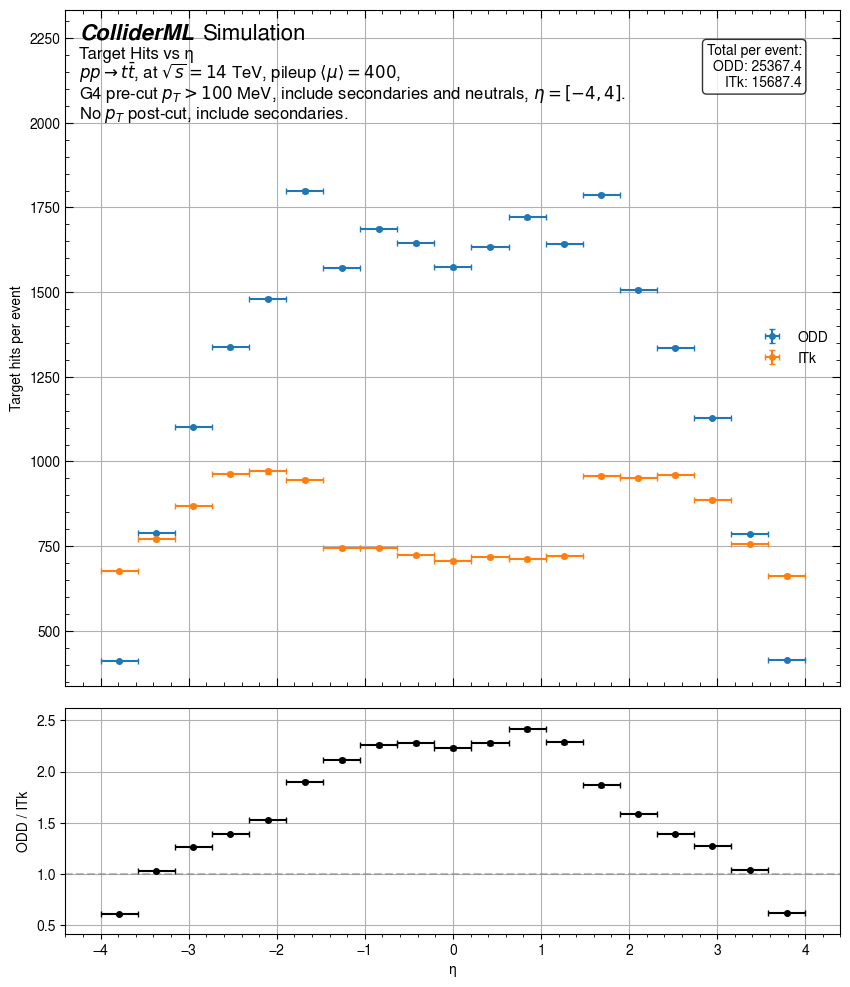

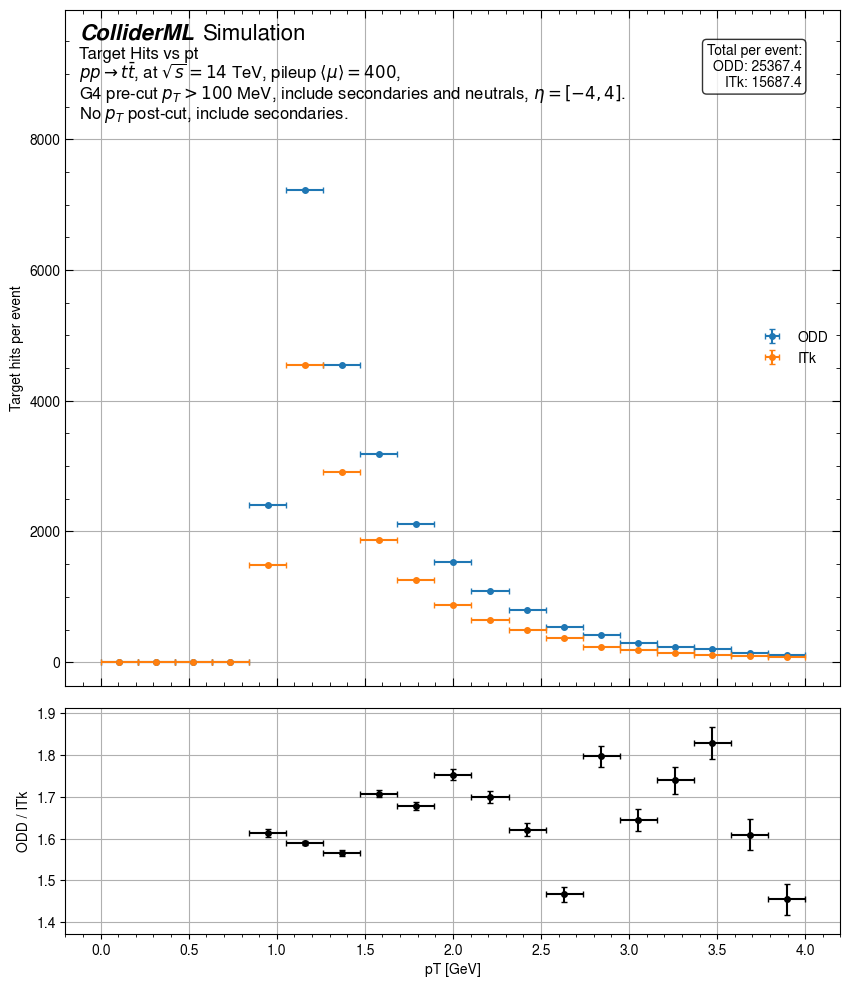

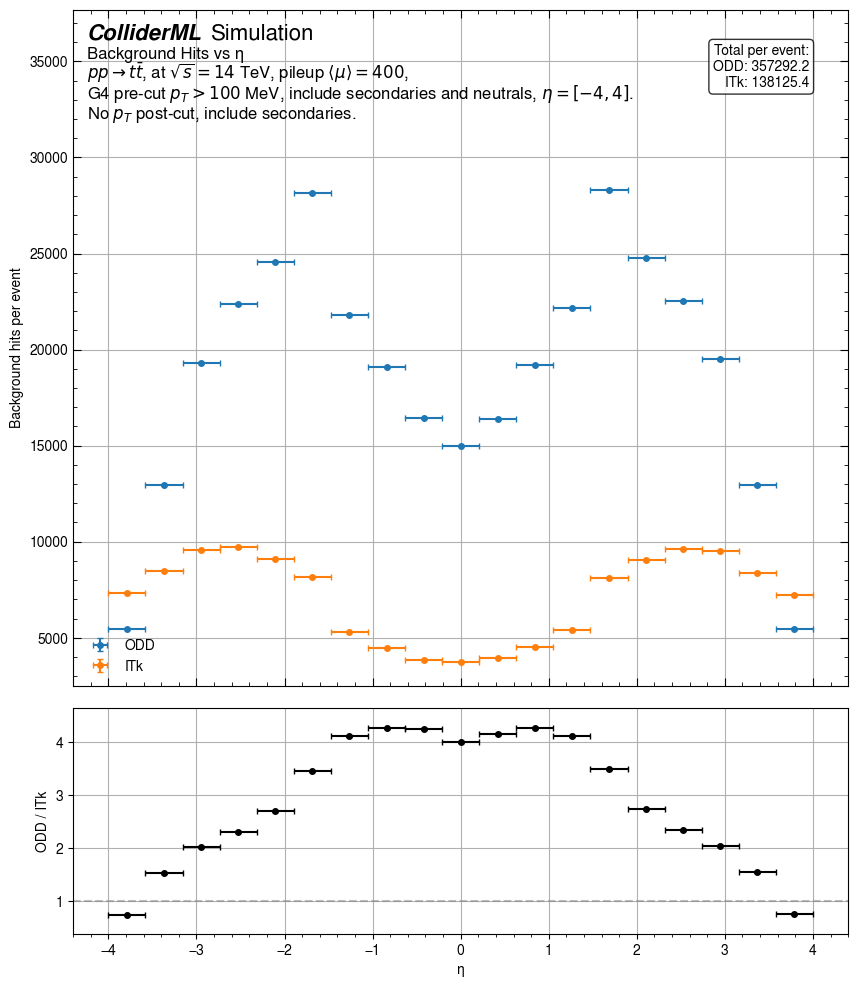

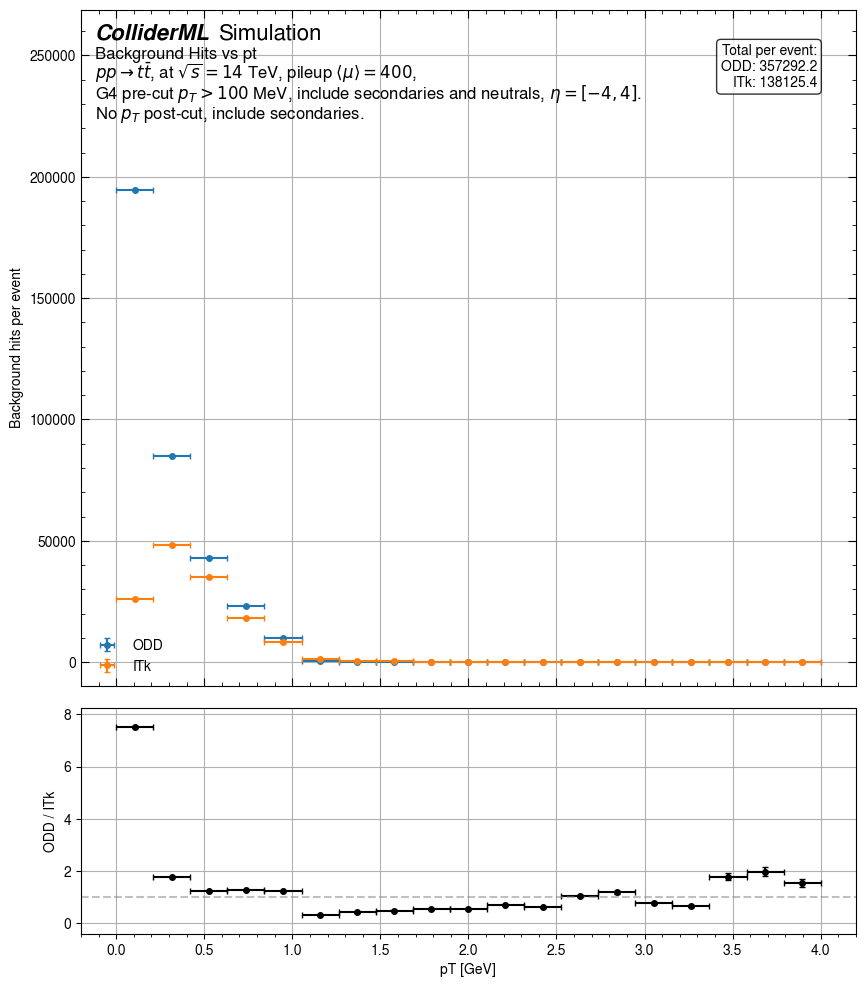

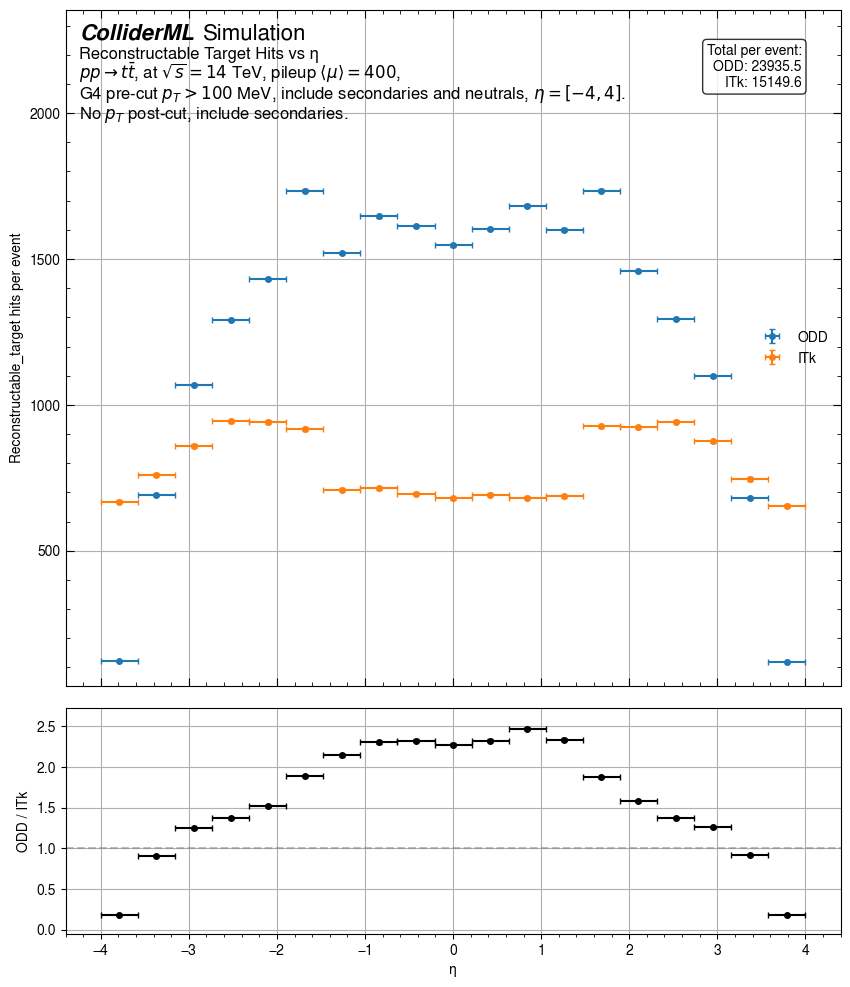

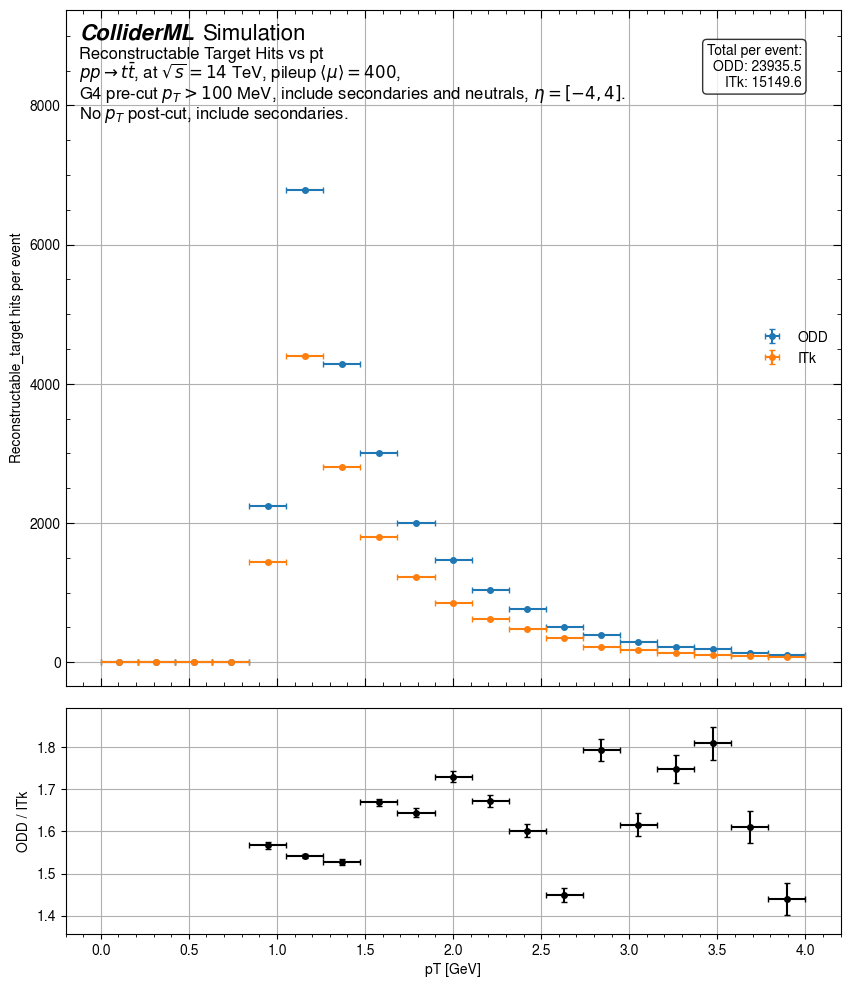

: 

: 

In [8]:
# Make hitwise comparison plots
make_comparison_plot(odd_data, itk_data, 'target', title="Target Hits vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'target', title="Target Hits vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'background', title="Background Hits vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'background', title="Background Hits vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_target', title="Reconstructable Target Hits vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_target', title="Reconstructable Target Hits vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_background', title="Reconstructable Background Hits vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_background', title="Reconstructable Background Hits vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, ['noise', 'neutral', 'background'], title="All non-target hits vs η", subtext=odd_config, save_dir=plot_dir)

# Make particlewise comparison plots
make_comparison_plot(odd_data, itk_data, 'target', plot_type='particles', title="Target Particles vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'target', plot_type='particles', title="Target Particles vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'background', plot_type='particles', title="Background Particles vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'background', plot_type='particles', title="Background Particles vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_target', plot_type='particles', title="Reconstructable Target Particles vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_target', plot_type='particles', title="Reconstructable Target Particles vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_background', plot_type='particles', title="Reconstructable Background Particles vs η", subtext=odd_config, save_dir=plot_dir)
make_comparison_plot(odd_data, itk_data, 'reconstructable_background', plot_type='particles', title="Reconstructable Background Particles vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)


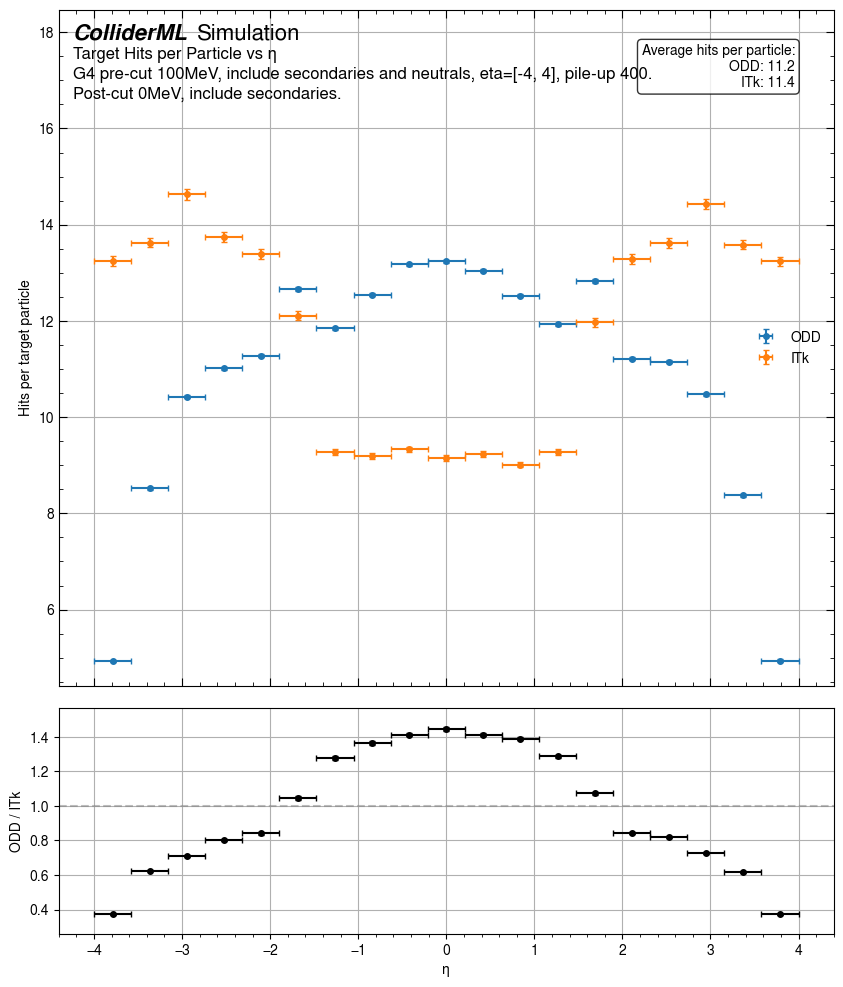

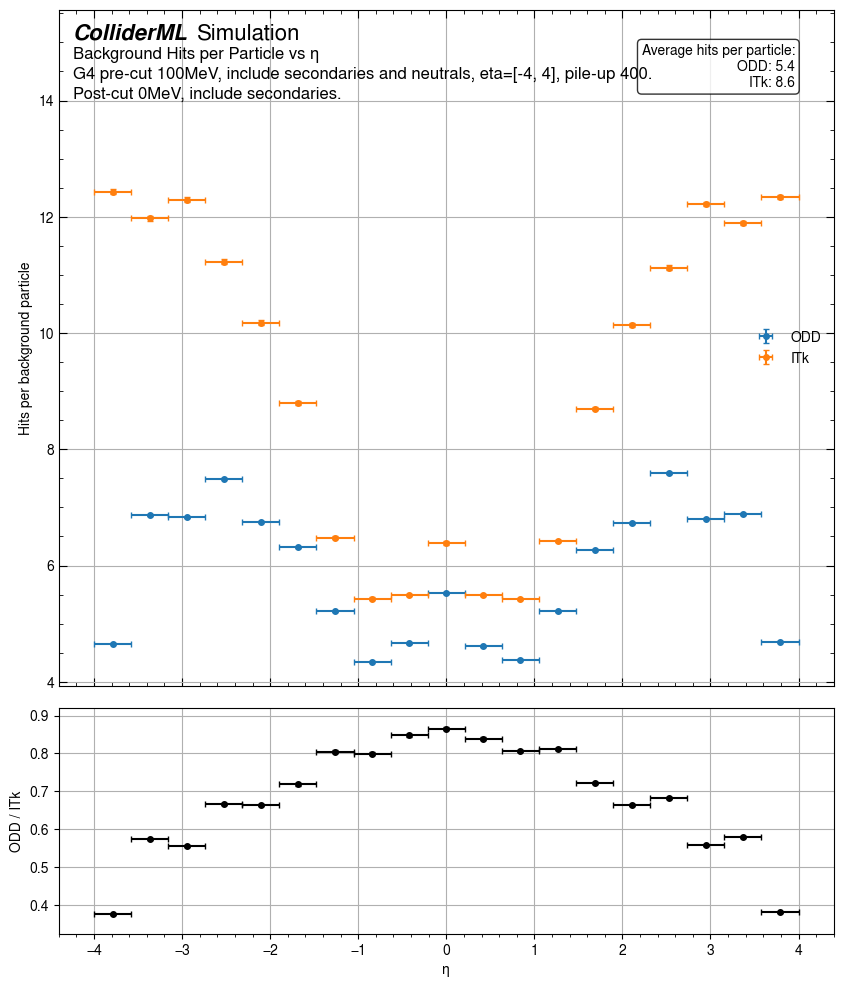

(<Figure size 1000x1200 with 2 Axes>,
 (<Axes: ylabel='Hits per background particle'>,
  <Axes: xlabel='η', ylabel='ODD / ITk'>))

In [16]:
# Make hits per particle plots
make_hits_per_particle_plot(odd_data, itk_data, 'target', title="Target Hits per Particle vs η", x_var='eta', bins=np.linspace(-4, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'target', title="Target Hits per Particle vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'background', title="Background Hits per Particle vs η", x_var='eta', bins=np.linspace(-4, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'background', title="Background Hits per Particle vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'reconstructable_target', title="Reconstructable Target Hits per Particle vs η", x_var='eta', bins=np.linspace(-4, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'reconstructable_target', title="Reconstructable Target Hits per Particle vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'reconstructable_background', title="Reconstructable Background Hits per Particle vs η", x_var='eta', bins=np.linspace(-4, 4, 20), subtext=odd_config, save_dir=plot_dir)
make_hits_per_particle_plot(odd_data, itk_data, 'reconstructable_background', title="Reconstructable Background Hits per Particle vs pt", x_var='pt', bins=np.linspace(0, 4, 20), subtext=odd_config, save_dir=plot_dir)